In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

In [11]:
data = load_iris()

In [12]:
iris = pd.DataFrame(data['data'], columns = data['feature_names'])

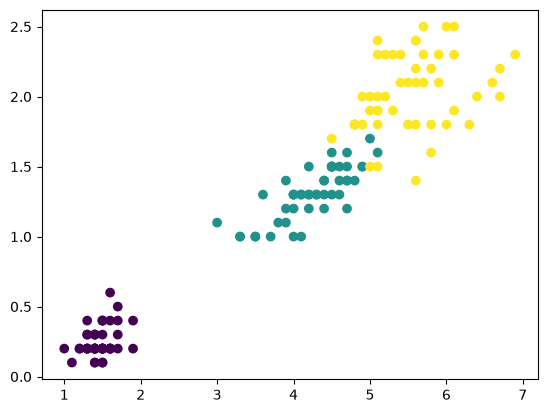

In [13]:
plt.scatter(x=iris['petal length (cm)'], y = iris['petal width (cm)'], c = data['target'])

In [15]:
KM = KMeans(n_clusters=3, algorithm='elkan' ,random_state=42)

In [17]:
output = KM.fit_predict(iris)

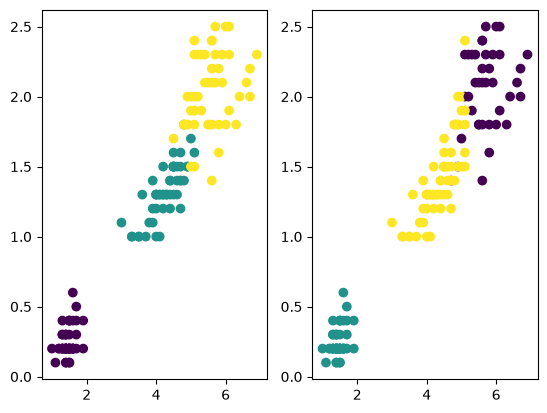

In [20]:
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)
ax1.scatter(x=iris['petal length (cm)'], y = iris['petal width (cm)'], c = data['target'])
ax2.scatter(x=iris['petal length (cm)'], y = iris['petal width (cm)'], c = output)

In [36]:
pg_data = sns.load_dataset('penguins')

In [37]:
pg_data.dropna(axis=0, inplace=True)

In [38]:
pg_data

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [39]:
from sklearn.preprocessing import LabelEncoder

In [40]:
encoder = LabelEncoder()

In [41]:
pg_data[['species','island','sex']] = pg_data.select_dtypes(include=object).apply(encoder.fit_transform)

C:\Users\memon\AppData\Local\Temp\ipykernel_53360\59428001.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  pg_data[['species','island','sex']] = pg_data.select_dtypes(include=object).apply(encoder.fit_transform)


In [43]:
y = pg_data['species']
pg_data.drop('species',axis=1, inplace=True)

In [44]:
pg_data

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,2,39.1,18.7,181.0,3750.0,1
1,2,39.5,17.4,186.0,3800.0,0
2,2,40.3,18.0,195.0,3250.0,0
4,2,36.7,19.3,193.0,3450.0,0
5,2,39.3,20.6,190.0,3650.0,1
...,...,...,...,...,...,...
338,0,47.2,13.7,214.0,4925.0,0
340,0,46.8,14.3,215.0,4850.0,0
341,0,50.4,15.7,222.0,5750.0,1
342,0,45.2,14.8,212.0,5200.0,0


In [45]:
k_range = range(1,11)

In [46]:
wcss = []

In [47]:
for k in k_range:
    KMean = KMeans(n_clusters=k)
    KMean.fit(pg_data)
    wcss.append(KMean.inertia_)

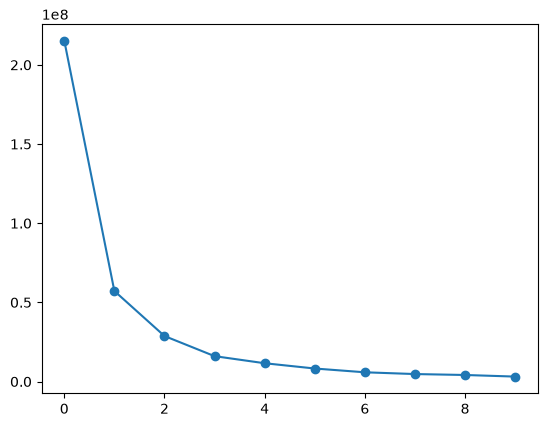

In [49]:
plt.plot(wcss, marker='o')

In [50]:
KM = KMeans(n_clusters=3)

In [51]:
output = KM.fit_predict(pg_data)

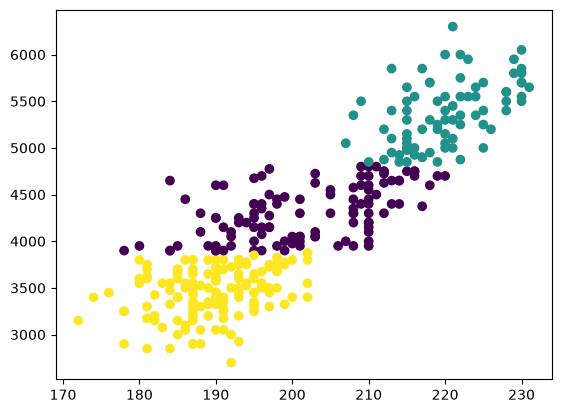

In [54]:
plt.scatter(pg_data.flipper_length_mm,	pg_data.body_mass_g, c = output)

In [61]:
ai_impact = pd.read_csv('ai_student_impact_dataset.csv')

In [62]:
ai_impact.drop('Student_ID', axis=1, inplace=True)

In [65]:
new_encoder = LabelEncoder()
ai_impact[["Major_Category","Year_of_Study","Primary_Use_Case","Prompt_Engineering_Skill","Institutional_Policy","Paid_Subscription","Burnout_Risk_Level"]] = ai_impact.select_dtypes(include=['object','bool']).apply(new_encoder.fit_transform)

C:\Users\memon\AppData\Local\Temp\ipykernel_53360\482551848.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  ai_impact[["Major_Category","Year_of_Study","Primary_Use_Case","Prompt_Engineering_Skill","Institutional_Policy","Paid_Subscription","Burnout_Risk_Level"]] = ai_impact.select_dtypes(include=['object','bool']).apply(new_encoder.fit_transform)


In [66]:
ai_impact

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,2,3,2.418,23.31,0,1,1,1,8.13,5,1,6,2.393,86.44,0
1,3,2,3.821,1.12,3,0,5,1,16.65,3,0,9,3.696,69.39,1
2,1,0,3.398,21.26,4,1,2,2,10.35,5,0,9,3.499,73.93,2
3,1,3,3.789,1.82,0,2,4,1,15.23,2,0,2,4.000,63.58,2
4,4,4,3.635,9.29,1,0,4,1,12.55,4,0,4,3.798,100.00,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,1,3,2.899,12.16,0,1,2,1,13.36,2,0,2,3.584,66.16,0
49996,4,3,2.870,2.51,0,2,1,0,4.67,3,0,3,3.096,81.62,2
49997,1,3,3.177,15.87,4,0,5,1,3.92,4,1,5,3.605,97.21,0
49998,1,2,3.398,19.91,1,2,5,1,7.10,5,0,3,3.527,84.12,2


In [67]:
WCSS = []
for k in range(1,11):
    km = KMeans(n_clusters=k)
    km.fit(ai_impact)
    WCSS.append(km.inertia_)

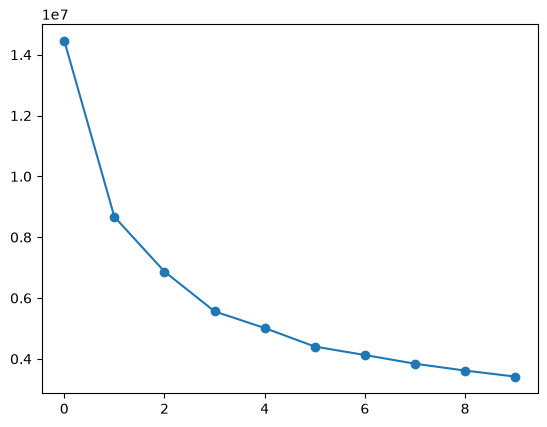

In [70]:
plt.plot(WCSS, marker = 'o')

In [77]:
km = KMeans(n_clusters=3, verbose=1)
output = km.fit_predict(ai_impact)

Initialization complete
Iteration 0, inertia 9421547.656396005.
Iteration 1, inertia 6898655.9798692465.
Iteration 2, inertia 6878816.409907491.
Iteration 3, inertia 6873048.437485438.
Iteration 4, inertia 6871412.65903996.
Iteration 5, inertia 6871022.094205983.
Iteration 6, inertia 6870903.900911923.
Iteration 7, inertia 6870873.549851877.
Converged at iteration 7: center shift 0.0011418781728094398 within tolerance 0.001928533081210203.


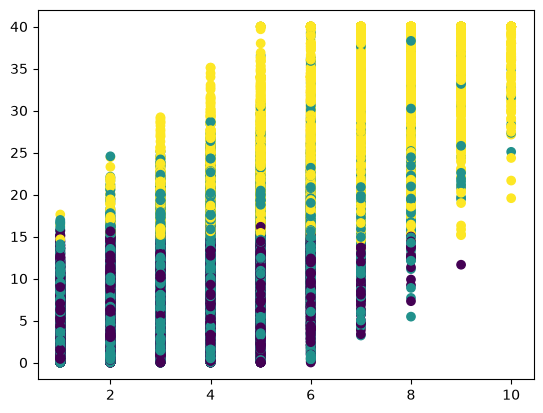

In [84]:
plt.scatter(ai_impact.Perceived_AI_Dependency,ai_impact.Weekly_GenAI_Hours, c=output)

In [79]:
ai_impact['target'] = output

<Axes: >

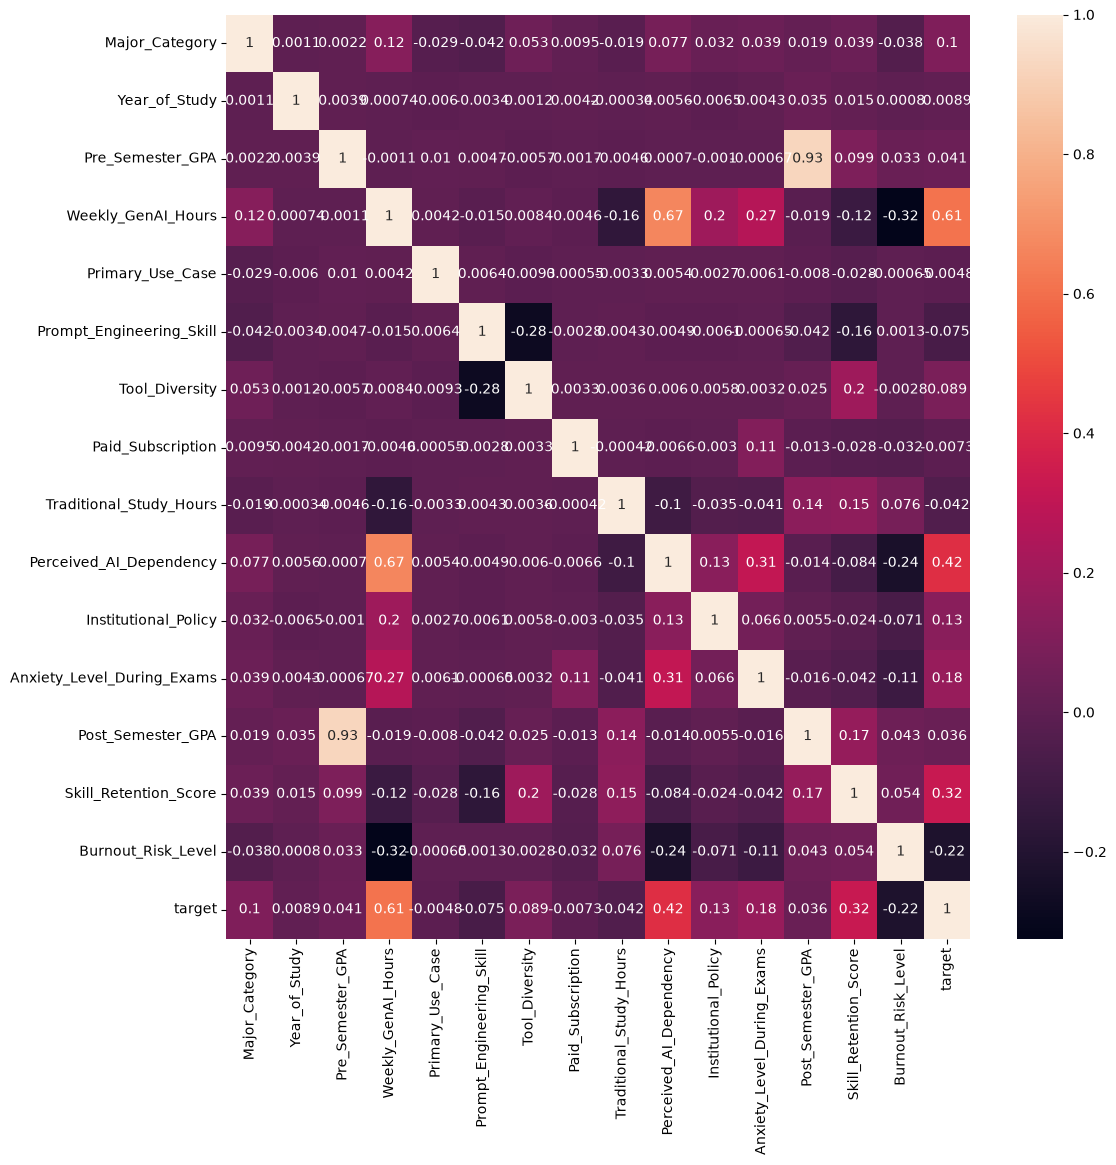

In [82]:
plt.figure(figsize=(12,12))
sns.heatmap(ai_impact.corr(), annot=True)